In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df_final=pd.read_csv('../data_processed/df_final_1.csv')

In [22]:
df_final.head()

,TIME_PERIOD,OBS_VALUE,Comune,Popolazione residente,Superficie (Kmq)
0,2001,5,Agliè,2545.0,13.1462
1,2002,5,Agliè,2545.0,13.1462
2,2003,4,Agliè,2545.0,13.1462
3,2004,9,Agliè,2545.0,13.1462
4,2005,2,Agliè,2545.0,13.1462


In [23]:
df_final.isnull().sum()

TIME_PERIOD              0
OBS_VALUE                0
Comune                   0
Popolazione residente    0
Superficie (Kmq)         0
dtype: int64

In [24]:
trend = df_final.groupby('TIME_PERIOD')['OBS_VALUE'].sum()

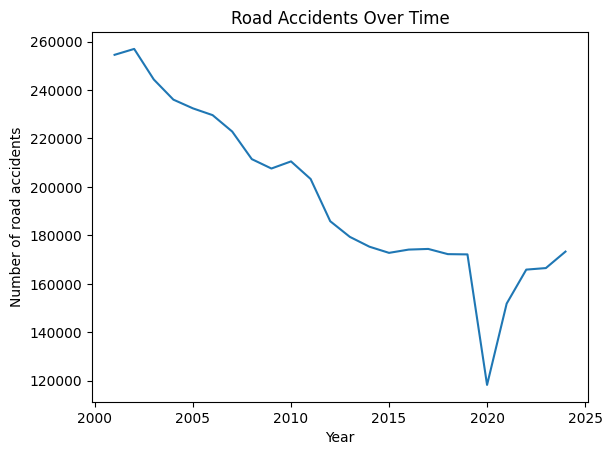

In [25]:
plt.plot(trend.index, trend.values)
plt.title('Road Accidents Over Time')
plt.xlabel('Year')
plt.ylabel('Number of road accidents')
plt.show()

In [26]:
top_comuni = (df_final
              .groupby('Comune')['OBS_VALUE']
              .sum().
              sort_values(ascending=False)
              .head(10)
              )

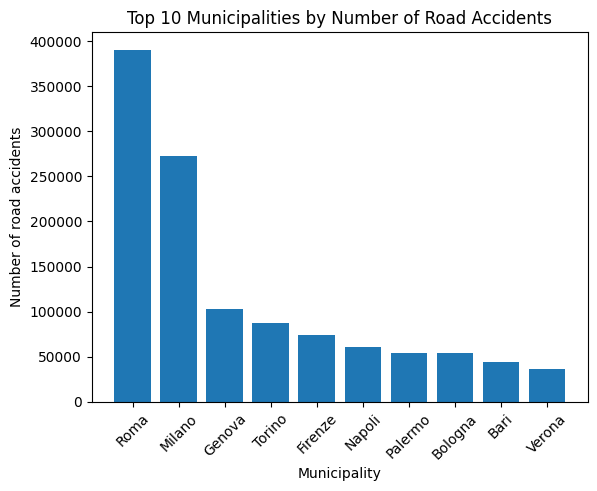

In [27]:
plt.bar(top_comuni.index, top_comuni.values)
plt.title('Top 10 Municipalities by Number of Road Accidents')
plt.xlabel('Municipality')
plt.ylabel('Number of road accidents')
plt.xticks(rotation=45)
plt.show()

In [28]:
df_final['Road_accident_per_resident'] = (
    df_final['OBS_VALUE']
    /
    df_final['Popolazione residente']
)

In [29]:
top_pop = (df_final
              .groupby('Comune')['Road_accident_per_resident']
              .mean()
              .sort_values(ascending=False)
              .head(10)
              )

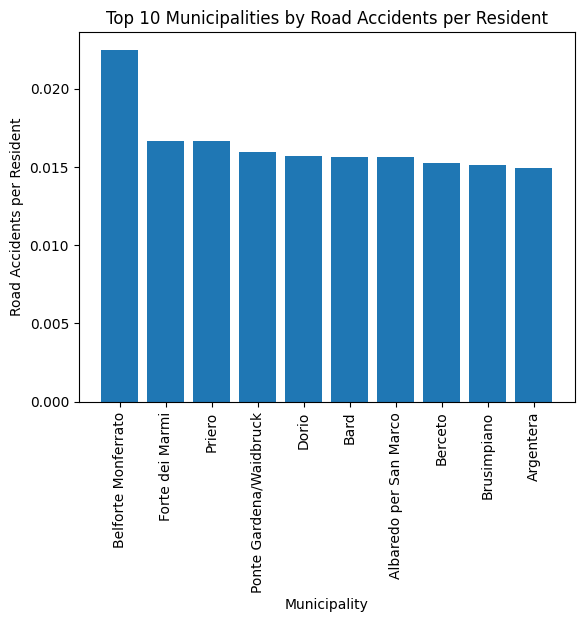

In [30]:
plt.bar( top_pop.index, top_pop.values)
plt.title('Top 10 Municipalities by Road Accidents per Resident')
plt.xlabel('Municipality')
plt.ylabel('Road Accidents per Resident')
plt.xticks(rotation=90)
plt.show()

In [31]:
df_final['Road_accident_per_Kmq'] = (
    df_final['OBS_VALUE']
    /
    df_final['Superficie (Kmq)']
)

In [32]:
df_final['Densità_della_popolazione'] = (
    df_final['Popolazione residente']
    /
    df_final['Superficie (Kmq)']
)

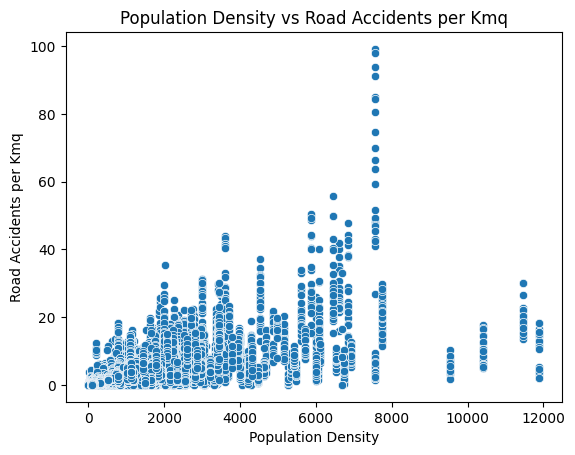

In [33]:
sns.scatterplot(
    data=df_final,
    x='Densità_della_popolazione',
    y='Road_accident_per_Kmq'
)
plt.title('Population Density vs Road Accidents per Kmq')
plt.xlabel('Population Density')
plt.ylabel('Road Accidents per Kmq')
plt.show()

In [34]:
top_10_roa_per_kmq = (df_final
              .groupby('Comune')['Road_accident_per_Kmq']
              .mean()
              .sort_values(ascending=False)
              .head(10)
              )

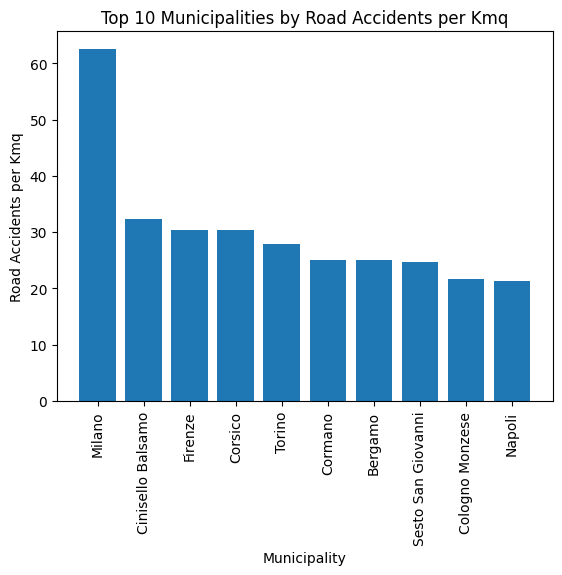

In [35]:
plt.bar(top_10_roa_per_kmq.index, top_10_roa_per_kmq.values)
plt.title('Top 10 Municipalities by Road Accidents per Kmq')
plt.xlabel('Municipality')
plt.ylabel('Road Accidents per Kmq')
plt.xticks(rotation=90)
plt.show()

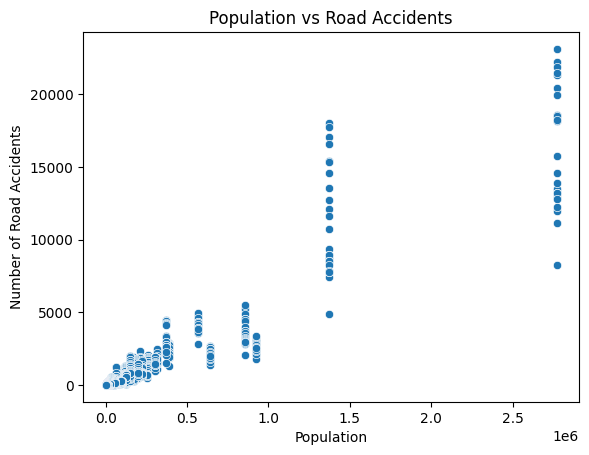

In [36]:
sns.scatterplot(
    data=df_final,
    x='Popolazione residente',
    y='OBS_VALUE'
)
plt.title('Population vs Road Accidents')
plt.xlabel('Population')
plt.ylabel('Number of Road Accidents')
plt.show()

In [37]:
df_final.head()

,TIME_PERIOD,OBS_VALUE,Comune,Popolazione residente,Superficie (Kmq),Road_accident_per_resident,Road_accident_per_Kmq,Densità_della_popolazione
0,2001,5,Agliè,2545.0,13.1462,0.001965,0.380338,193.592065
1,2002,5,Agliè,2545.0,13.1462,0.001965,0.380338,193.592065
2,2003,4,Agliè,2545.0,13.1462,0.001572,0.304270,193.592065
3,2004,9,Agliè,2545.0,13.1462,0.003536,0.684608,193.592065
4,2005,2,Agliè,2545.0,13.1462,0.000786,0.152135,193.592065


In [38]:
df_final.to_csv('../data_processed/df_final_1.csv', index=False)

KEY FINDINGS

The EDA shows that road accidents are mainly concentrated in large urban areas. However when road accidents are expressed as relative indicatos, different municipalities emerge, highlighting the importance of comparing relative measures alongside absolute values. Over time, road accidents show an overall decreasing trend, with a sharp drop in 2020 followed by a gradual recovery. Finally, the scatter plos suggest a positive association between popolation, population density and the number of road accidents